In [25]:
import numpy as np
import pandas as pd
#import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [26]:
atl_zips = pd.read_csv("../../master_datasets/crime_datasets/atlanta_zip_codes.csv")
atl_zips['zipcode'] = atl_zips.zip.astype('int')

In [27]:
crime = pd.read_csv("../../master_datasets/crime_datasets/crime_counts.csv") # for testing

In [28]:
atl_zips

,zip,zipcode
0,30303,30303
1,30305,30305
2,30306,30306
3,30307,30307
4,30308,30308
5,30309,30309
6,30310,30310
7,30311,30311
8,30312,30312
9,30313,30313


In [29]:
atl_zip_shp = gpd.read_file('../../master_datasets/crime_datasets/crime_datasets/tl_2022_us_zcta520.zip')

In [30]:
atl_zip_shp

,ZCTA5CE20,GEOID20,CLASSFP20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,geometry
0,47236,47236,B5,G6350,S,1029063,0,+39.1517426,-085.7252769,"POLYGON ((-85.7341 39.15597, -85.72794 39.1561..."
1,47870,47870,B5,G6350,S,8830,0,+39.3701518,-087.4735141,"POLYGON ((-87.47414 39.37016, -87.47409 39.370..."
2,47851,47851,B5,G6350,S,53326,0,+39.5735839,-087.2459559,"POLYGON ((-87.24769 39.5745, -87.24711 39.5744..."
3,47337,47337,B5,G6350,S,303089,0,+39.8027537,-085.4372850,"POLYGON ((-85.44357 39.80328, -85.44346 39.803..."
4,47435,47435,B5,G6350,S,13302,0,+39.2657557,-086.2951577,"POLYGON ((-86.29592 39.26547, -86.29592 39.266..."
...,...,...,...,...,...,...,...,...,...,...
33786,37932,37932,B5,G6350,S,75093217,4374995,+35.9172993,-084.1987873,"POLYGON ((-84.27347 35.93928, -84.27287 35.940..."
33787,37341,37341,B5,G6350,S,87434962,27139990,+35.2199309,-085.0730025,"POLYGON ((-85.1509 35.11231, -85.15088 35.1123..."
33788,37849,37849,B5,G6350,S,102931713,896866,+36.0540502,-084.0484876,"POLYGON ((-84.14857 36.04234, -84.1424 36.0468..."
33789,37754,37754,B5,G6350,S,99003113,145391,+36.1390993,-084.0298007,"POLYGON ((-84.10549 36.11168, -84.10543 36.111..."


In [31]:
atl_zip_shp.rename(columns = {'GEOID20':'zipcode'}, inplace = True)
atl_zip_shp.zipcode = atl_zip_shp.zipcode.astype('int')

filtered_atl_zip_shp = atl_zip_shp[atl_zip_shp['zipcode'].isin(atl_zips['zipcode'])].reset_index()

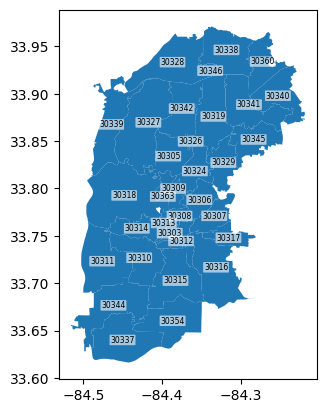

In [32]:
ax = filtered_atl_zip_shp.plot()

for x, y, label in zip(filtered_atl_zip_shp.INTPTLAT20.astype(float),
                       filtered_atl_zip_shp.INTPTLON20.astype(float),
                       filtered_atl_zip_shp.zipcode.astype(str)):
    ax.annotate(label,
               xy=(y, x),
               xytext=(0, 0),
               textcoords="offset points",
               ha='center',
               va='center',
               fontsize=5.5,
               bbox=dict(
                   boxstyle='round,pad=0.1',
                   facecolor='white',
                   edgecolor='none',
                   alpha=0.6
               ))

In [33]:
zip_crime = pd.merge(filtered_atl_zip_shp, crime, on='zipcode')

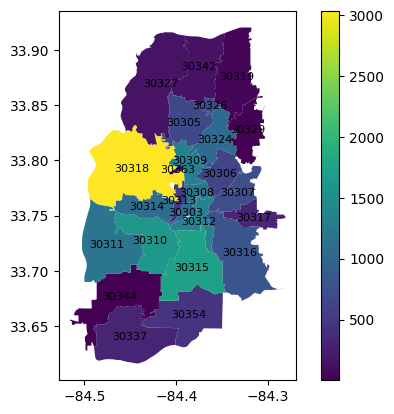

In [34]:
ax = zip_crime.plot(column= 'crime_count',legend=True)

for x, y, label in zip(zip_crime.INTPTLAT20.astype('float'), zip_crime.INTPTLON20.astype('float'), zip_crime.zipcode.astype('str')):
  ax.annotate(label, xy=(y,x), xytext=(0, 0), textcoords="offset points", ha = 'center', va = 'center',fontsize = 8)

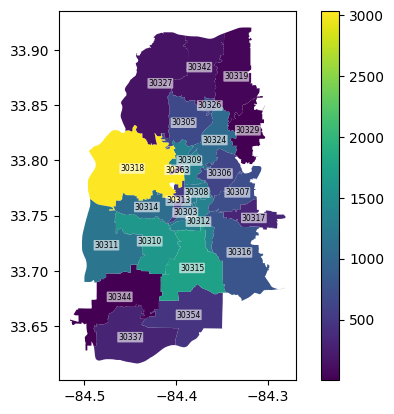

In [35]:
ax = zip_crime.plot(column='crime_count', legend=True)

for x, y, label in zip(zip_crime.INTPTLAT20.astype(float),
                       zip_crime.INTPTLON20.astype(float),
                       zip_crime.zipcode.astype(str)):
    ax.annotate(label,
               xy=(y, x),
               xytext=(0, 0),
               textcoords="offset points",
               ha='center',
               va='center',
               fontsize=5.5,
               bbox=dict(
                   boxstyle='round,pad=0.1',
                   facecolor='white',
                   edgecolor='none',
                   alpha=0.6
               ))